In [1]:
import argparse
import os
import re

import torch.nn.functional as F

os.environ["TORCHINDUCTOR_DISABLE"] = "1"
os.environ["TORCH_COMPILE"] = "0"
os.environ["TORCHDYNAMO_DISABLE"] = "1"
os.environ["DISABLE_TORCH_COMPILE"] = "1"
os.environ["TRANSFORMERS_NO_COMPILE"] = "1"
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from safetensors.torch import load_file as load_safetensors
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (adjusted_rand_score, balanced_accuracy_score,
                             calinski_harabasz_score, classification_report,
                             davies_bouldin_score, pairwise_distances,
                             silhouette_score)
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
from sklearn.model_selection import train_test_split
import pandas as pd
import seaborn as sns
import umap
import glob
from scipy.stats import spearmanr


In [2]:
models = [ "google/gemma-2-2b-it", "meta-llama/Llama-3.2-3B-Instruct", "google/gemma-2-2b", "meta-llama/Llama-3.2-3B",
           "Qwen/Qwen2.5-3B", "Qwen/Qwen2.5-3B-Instruct", "allenai/OLMo-2-0425-1B", "allenai/OLMo-2-0425-1B-Instruct"]


output_dir = "/data/erblina/Master_thesis"

datasets_list = ["walledai/AdvBench","walledai/DTStereotype", "walledai/CatHarmfulQA","walledai/DTToxicity","truthfulqa/truthful_qa"]


model_steering_1 = {'Qwen/Qwen2.5-3B': {'layers': [ 'model.layers.19', 'model.layers.20', 'model.layers.22'], 'alphas_up': [ 1.6, 1.6, 1.6], 'alphas_down': [ -1.8, -2.0, -2.0], 'max_avg_tox': [0.87, 0.87, 0.795, 0.76], 'min_avg_tox': [0.21, 0.21, 0.22, 0.19]},
    'Qwen/Qwen2.5-3B-Instruct': {'layers': [ 'model.layers.21', 'model.layers.20', 'model.layers.22'], 'alphas_up': [ 2.0, 2.0, 2.0], 'alphas_down': [ -0.6, -0.6, -0.6], 'max_avg_tox': [0.79, 0.79, 0.785, 0.78], 'min_avg_tox': [0.0, 0.0, 0.0, 0.0]},
    'allenai/OLMo-2-0425-1B-Instruct': {'layers': [ 'model.layers.9', 'model.layers.7', 'model.layers.8'], 'alphas_up': [ 2.0, 1.8, 1.6], 'alphas_down': [ -0.8, -1.0, -0.8], 'max_avg_tox': [0.75, 0.75, 0.735, 0.715], 'min_avg_tox': [0.0, 0.0, 0.0, 0.0]},
    'allenai/OLMo-2-0425-1B': {'layers': ['model.layers.5', 'model.layers.7', 'model.layers.4'], 'alphas_up': [-0.15, -0.07, 0.05], 'alphas_down': [-2.0, -1.5, -2.0], 'max_avg_tox': [0.4, 0.39, 0.39], 'min_avg_tox': [0.09, 0.085, 0.09]},
    'google/gemma-2-2b-it': {'layers': [ 'model.layers.10', 'model.layers.11', 'model.layers.12'], 'alphas_up': [ 1.5, 1.1, 1.0], 'alphas_down': [-0.3, -0.25, -0.2], 'max_avg_tox': [0.63, 0.63, 0.615, 0.595], 'min_avg_tox': [0.0, 0.0, 0.0, 0.0]},
    'meta-llama/Llama-3.2-3B-Instruct': {'layers': [ 'model.layers.12', 'model.layers.13', 'model.layers.14'], 'alphas_up': [ 2.0, 1.6, 2.0], 'alphas_down': [ -0.8, -0.5, -0.5], 'max_avg_tox': [0.82, 0.82, 0.81, 0.79], 'min_avg_tox': [0.0, 0.0, 0.0, 0.0]},
    'google/gemma-2-2b': {'layers': [ 'model.layers.6', 'model.layers.7', 'model.layers.13'], 'alphas_up': [ 1.2, 1.3, 1.4], 'alphas_down': [ -2.0, -1.8, -1.8], 'max_avg_tox': [0.36, 0.36, 0.35, 0.36], 'min_avg_tox': [0.135, 0.02, 0.035, 0.065]},
    'meta-llama/Llama-3.2-3B': {'layers': [ 'model.layers.12', 'model.layers.10', 'model.layers.11'], 'alphas_up': [ 0.7, 1.0, 1.0], 'alphas_down': [ -2.0, -1.4, -1.6], 'max_avg_tox': [0.605, 0.57, 0.575, 0.6], 'min_avg_tox': [0.385, 0.3, 0.33, 0.36]},
        }

In [ ]:
def load_harmbench(model, output_dir):
    safe_model_name = re.sub(r'[\\/*?:"<>|]', "_", model)

    ###### HARMBENCH DATASET ######
    labels = np.load(f"{output_dir}/{safe_model_name}/labels.npy")
    hidden_states = load_safetensors(
        os.path.join(f"{output_dir}/{safe_model_name}", f"hidden_states_pure.safetensors"))
    
    side = 'toxic'
    

    return hidden_states, labels #, data

def load_datasets(model, dataset, output_dir):
    safe_model_name = re.sub(r'[\\/*?:"<>|]', "_", model)

    safe_dataset = re.sub(r'[\\/*?:"<>|]', "_", dataset)
    hidden_states_data = load_safetensors(os.path.join(output_dir, safe_model_name, f"{safe_dataset}_hidden_states_pure.safetensors"))
    labels_data = np.load(f"{output_dir}/{safe_model_name}/labels_{safe_dataset}.npy")

    return hidden_states_data, labels_data

def load_steering_dataset(model, dataset, model_steering_1, output_dir):
    side = 'toxic'
    safe_model_name = re.sub(r'[\\/*?:"<>|]', "_", model)
    safe_dataset = re.sub(r'[\\/*?:"<>|]', "_", dataset)
        # Find the layer corresponding to the given alpha
    layers = model_steering_1[model]['layers']
    data = {}
    for layer in layers:
        alpha = model_steering_1[model]['alphas_up'][layers.index(layer)] # or alphas_down
        labels_after_dataset = np.load(
                f"{output_dir}/{safe_model_name}/labels_steering_{side}_alpha_{alpha}_{safe_dataset}_{layer}.npy", allow_pickle=True).item()[layer]

        alpha_d = model_steering_1[model]['alphas_down'][layers.index(layer)]
        labels_after_dataset_d = np.load(
                f"{output_dir}/{safe_model_name}/labels_steering_{side}_alpha_{alpha_d}_{safe_dataset}_{layer}.npy", allow_pickle=True).item()[layer]

        data[layer] = {
            alpha : labels_after_dataset,
            alpha_d : labels_after_dataset_d
        }

    return data

def load_steering_harmbench(model, model_steering_1, output_dir):
    side = 'toxic'
    safe_model_name = re.sub(r'[\\/*?:"<>|]', "_", model)
        # Find the layer corresponding to the given alpha
    layers = model_steering_1[model]['layers']
    data = {}
    for layer in layers:
        alpha = model_steering_1[model]['alphas_up'][layers.index(layer)] # or alphas_down
        labels_after = np.load(
                f"{output_dir}/{safe_model_name}/labels_steering_{side}_alpha_{alpha}_{layer}.npy", allow_pickle=True).item()[layer]

        alpha_d = model_steering_1[model]['alphas_down'][layers.index(layer)]
        labels_after_d = np.load(
                f"{output_dir}/{safe_model_name}/labels_steering_{side}_alpha_{alpha_d}_{layer}.npy", allow_pickle=True).item()[layer]

        data[layer] = {
            alpha : labels_after,
            alpha_d : labels_after_d
        }

    return data

def load_harmbench_atten(model, output_dir):
    safe_model_name = re.sub(r'[\\/*?:"<>|]', "_", model)

    ###### HARMBENCH DATASET ######
    attentions = load_safetensors(
        os.path.join(f"{output_dir}/{safe_model_name}", f"attention_states_pure.safetensors"))
    layer_names = sorted(list(attentions.keys()), key=lambda x: int(x.split('.')[2]))
    atten_flat = {}
    for key in layer_names:
        a = attentions[key].reshape(attentions[key].shape[0], -1)
        atten_flat[key] = a
        
    labels = np.load(f"{output_dir}/{safe_model_name}/labels.npy")
    return attentions, atten_flat, labels

def load_datasets_atten(model, dataset, output_dir):
    safe_model_name = re.sub(r'[\\/*?:"<>|]', "_", model)

    safe_dataset = re.sub(r'[\\/*?:"<>|]', "_", dataset)
    hidden_states_data = load_safetensors(os.path.join(output_dir, safe_model_name, f"{safe_dataset}_attention_states_pure.safetensors"))
    labels_data = np.load(f"{output_dir}/{safe_model_name}/labels_{safe_dataset}.npy")

    layer_names = sorted(list(hidden_states_data.keys()), key=lambda x: int(x.split('.')[2]))

    atten_flat = {}
    for key in layer_names:
        a = hidden_states_data[key].reshape(hidden_states_data[key].shape[0], -1)
        atten_flat[key] = a

        
    return hidden_states_data, atten_flat, labels_data

[[0.12356182]]


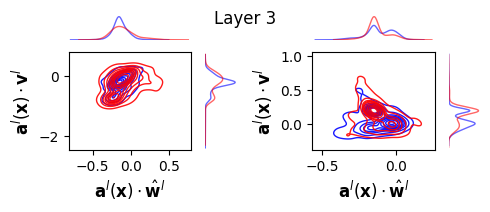

[[0.20956225]]


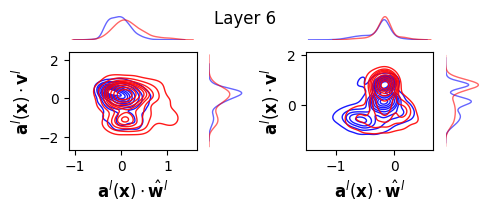

[[0.17219065]]


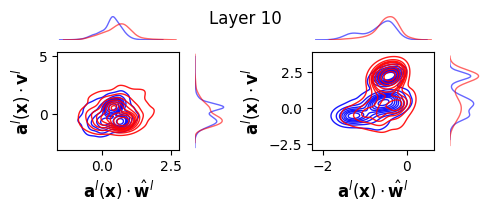

[[0.24172236]]


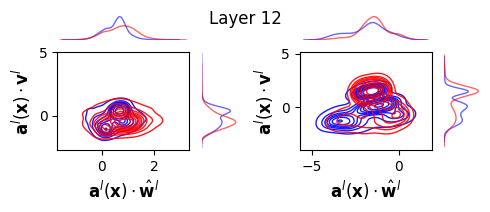

[[0.06356832]]


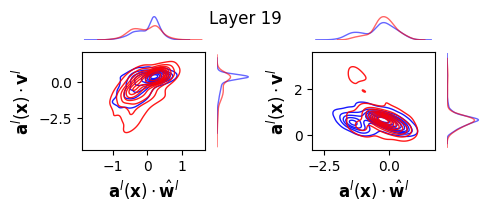

[[0.09992207]]


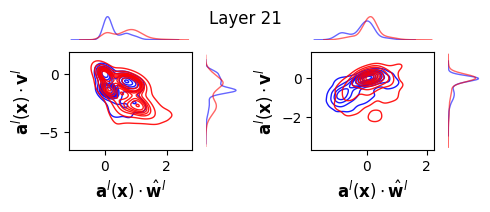

[[-0.02047609]]


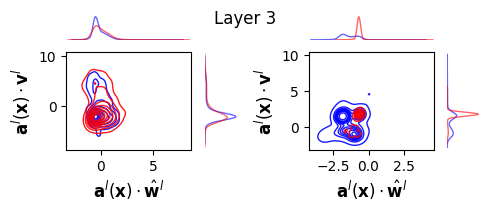

[[0.53450203]]


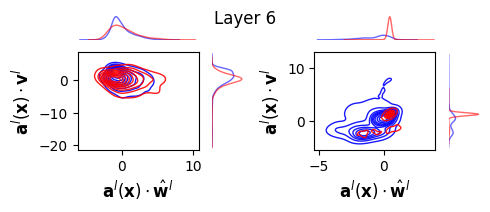

[[0.14306837]]


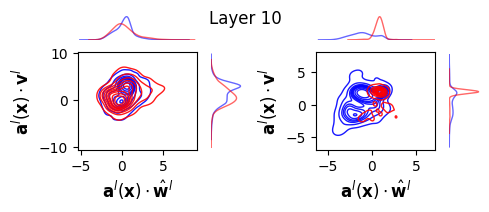

[[0.19635248]]


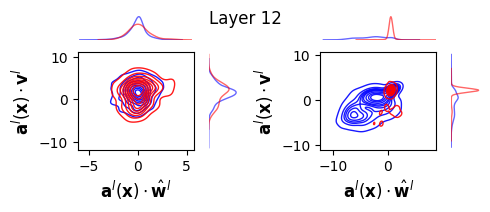

[[0.08064796]]


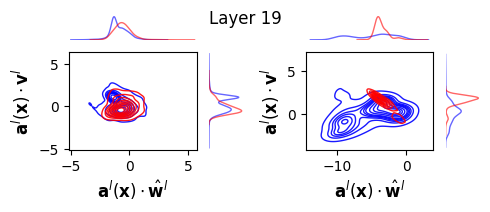

[[-0.03654206]]


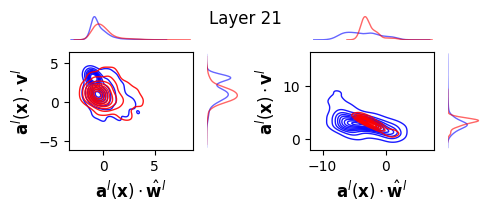

[[0.07214166]]


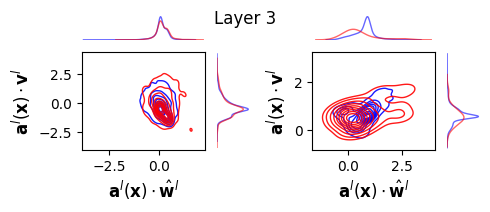

[[-0.04776263]]


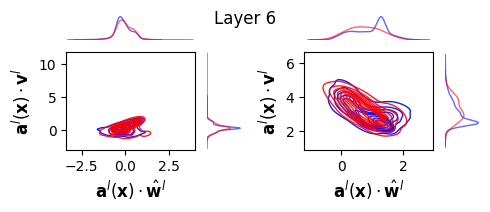

[[-0.060228]]


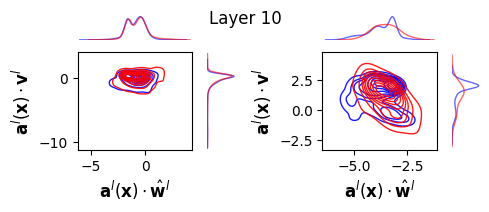

[[-0.05292415]]


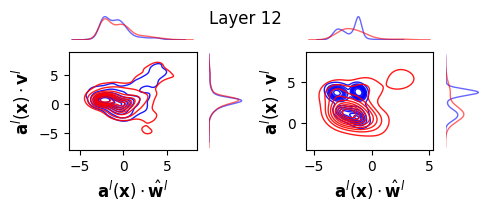

[[-0.51521138]]


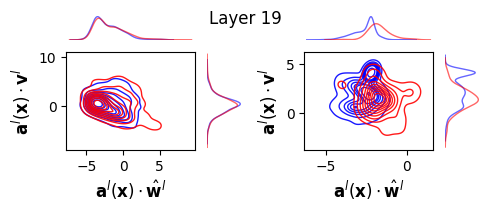

[[-0.1194105]]


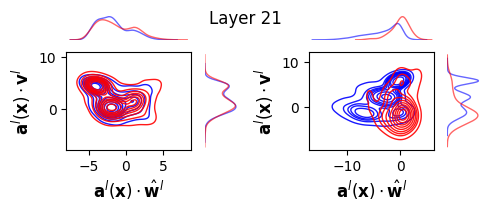

[[0.0208312]]


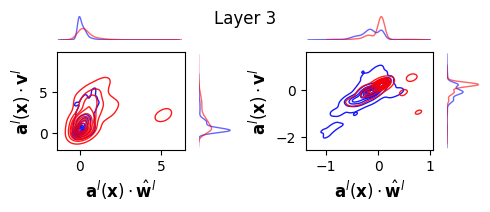

[[-0.04708574]]


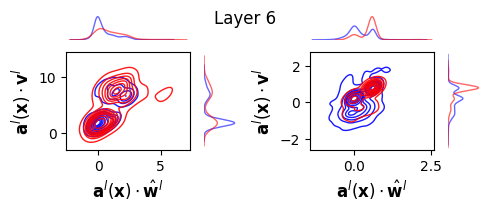

[[0.01821354]]


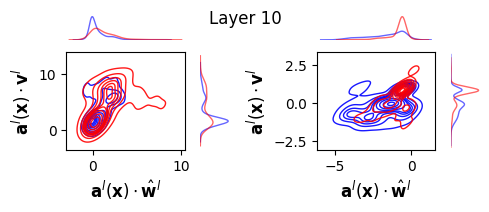

[[0.00268616]]


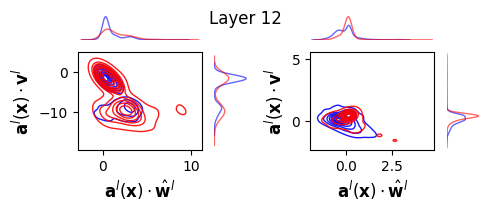

In [8]:
from sklearn.metrics import roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

def plot_kde_panel_with_marginals(fig, outer_position, x1, x2, y,
                                  title="", xlabel="", ylabel=""):
    """
    Draw a single panel (with top/right marginals) inside a 2x2 outer layout.
    """
    # Create a nested gridspec inside the given outer cell
    outer = fig.add_gridspec(3, 2)
    gs = outer[outer_position[0], outer_position[1]].subgridspec(4, 4)

    # Central 2D KDE
    ax_joint = fig.add_subplot(gs[1:,:-1])
    ax_marg_x = fig.add_subplot(gs[0,:-1], sharex=ax_joint)
    ax_marg_y = fig.add_subplot(gs[1:,-1], sharey=ax_joint)

    # Plot both classes
    for label, color in zip([0,1], ['blue', 'red']):
        sns.kdeplot(x=x1[y==label], y=x2[y==label],
                    ax=ax_joint, fill=False, color=color, alpha=0.9, levels=10, linewidths=1, bw_adjust=1.2)
        sns.kdeplot(x=x1[y==label], ax=ax_marg_x,
                    fill=False, alpha=0.6, color=color, linewidth=1, bw_adjust=1.2)
        sns.kdeplot(y=x2[y==label], ax=ax_marg_y,
                    fill=False, alpha=0.6, color=color, linewidth=1, bw_adjust=1.2)

    # Hide tick labels for marginals
    plt.setp(ax_marg_x.get_xticklabels(), visible=False)
    plt.setp(ax_marg_y.get_yticklabels(), visible=False)
    #  Remove tick labels and axis boxes for marginals
    ax_marg_x.set_axis_off()
    ax_marg_y.set_axis_off()

    # Labels & title
    ax_joint.set_xlabel(xlabel, size=12)
    ax_joint.set_ylabel(ylabel, size=12)
    # ax_joint.set_title(title, fontsize=9)
    # ax_marg_x.set_title(title, fontsize=9, pad=8)




    # Tighten layout within each panel
    plt.tight_layout()#pad=0.3)
    # Labels & title

    return ax_joint  # return central axis if needed


models = [( "meta-llama/Llama-3.2-3B", "meta-llama/Llama-3.2-3B-Instruct"), ("google/gemma-2-2b", "google/gemma-2-2b-it"),
          ("Qwen/Qwen2.5-3B", "Qwen/Qwen2.5-3B-Instruct"), ("allenai/OLMo-2-0425-1B", "allenai/OLMo-2-0425-1B-Instruct")]


def get_second_dir(X,y,  w, method='mean'):
    # normalize w
    w1 = w / (np.linalg.norm(w) + 1e-12)

    # projector onto orthogonal complement
    P_perp = np.eye(w1.size) - np.outer(w1, w1)
    if method == 'mean':

        Xp = X @ P_perp
        mu1 = Xp[y==1].mean(0)
        mu0 = Xp[y==0].mean(0)
        w2 = mu1 - mu0            # residual mean diff
        n = np.linalg.norm(w2) + 1e-12
        w2 = w2 / n
        auc = np.nan
    elif method == 'pca':
        Xc = X - X.mean(axis=0, keepdims=True)     # center data
        w1 = w / np.linalg.norm(w)

        # --- find new direction orthogonal to w with largest variance ---
        # deflate along w
        X_res = Xc - np.outer(Xc @ w1, w1)

        # SVD of the residual data
        _, _, Vt = np.linalg.svd(X_res, full_matrices=False)
        w2 = Vt[0]  
        auc = np.nan
    else:
        X_perp = X @ P_perp
        clf = LogisticRegression(max_iter=2000).fit(X_perp, y)
        w2 = clf.coef_.ravel()
        w2 = w2 / (np.linalg.norm(w2) + 1e-12)
        yhat = clf.predict(X_perp)
        auc = balanced_accuracy_score(y, yhat)
        auc = roc_auc_score(y, clf.decision_function(X_perp))

        w2_res = clf.coef_.ravel()
        w2_orig = P_perp @ w2_res
        w2 /= (np.linalg.norm(w2_orig) + 1e-12)

    return w2, auc
k = 'output'
for pair in models:
    
    model_base, model_it = pair
    safe_base = re.sub(r'[\\/*?:"<>|]', "_", model_base)
    safe_it = re.sub(r'[\\/*?:"<>|]', "_", model_it)
    # Load A
    X1b, X_1b, v1b = load_harmbench_atten(model_base, output_dir)
    layer_names = sorted(list(X_1b.keys()), key=lambda x: int(x.split('.')[2]))
    yb = (v1b > 0).astype(int)
    # Load B
    X1i, X_1i, v1i = load_harmbench_atten(model_it, output_dir)
    yi = (v1i > 0).astype(int)
    if k != 'output':
        X_1b = {layer: X1b[layer].mean(1) for layer in layer_names}
        X_1i = {layer: X1i[layer].mean(1) for layer in layer_names}
        
    steering_vector_a = {}
    steering_vector_b = {}
    for layer in layer_names:
        a = X_1b[layer][yb==1].float().mean(0) - X_1b[layer][yb==0].float().mean(0)
        steering_vector_a[layer] = { 'toxic': a }

        b = X_1i[layer][yi==1].float().mean(0) - X_1i[layer][yi==0].float().mean(0)
        steering_vector_b[layer] = { 'toxic': b }
    # steering_vector_a = torch.load(os.path.join(f"{output_dir}/{safe_base}", "steering_vectors.pt"))
    # steering_vector_b = torch.load(os.path.join(f"{output_dir}/{safe_it}", "steering_vectors.pt"))

    X_datab = []
    y_datab = []
    X_datai = []
    y_datai = []

    for data in datasets_list:
        X_db, X_d_b, y_d_b = load_datasets_atten(model_base, data, output_dir)
        y_d_b = (y_d_b > 0).astype(int)
        if k != 'output':
            X_d_b = {layer: X_db[layer].mean(1) for layer in layer_names}

        X_datab.append(X_d_b)
        y_datab.append(y_d_b)

        Xdi, X_d_i, y_d_i = load_datasets_atten(model_it, data, output_dir)
        y_d_i = (y_d_i > 0).astype(int)
        if k != 'output':
            X_d_i = {layer: Xdi[layer].mean(1) for layer in layer_names}
        X_datai.append(X_d_i)
        y_datai.append(y_d_i)


    t = 'toxic'
    res_base = {}
    res_it = {}
    layer_names = [layer for layer in layer_names if int(layer.split('.')[2]) in [3, 19, 21, 10, 12, 6]]
    for i, layer in enumerate(layer_names):
        res_base[layer] = {}
        res_it[layer] = {}
        X_allb = []
        y_allb = []
        X_alli = []
        y_alli = []

        X_allb.append(X_1b[layer].float().numpy())
        y_allb.append(yb)
        X_alli.append(X_1i[layer].float().numpy())
        y_alli.append(yi)

        for data in X_datab:
            X_allb.append(data[layer].float().numpy())
        for labels in y_datab:
            y_allb.append(labels)

        for data in X_datai:
            X_alli.append(data[layer].float().numpy())
        for labels in y_datai:
            y_alli.append(labels)
        
        X_allb = np.concatenate(X_allb, axis=0)
        y_allb = np.concatenate(y_allb, axis=0)
        X_alli = np.concatenate(X_alli, axis=0)
        y_alli = np.concatenate(y_alli, axis=0)

        for method in ['mean', 'logreg', 'pca']:
            res_base[layer][method] = []
            res_it[layer][method] = []

        for method in ['mean', 'pca', 'logreg']:
            # Get first steering vector
            w1_b = steering_vector_a[layer][t].float().numpy()
            w1_it= steering_vector_b[layer][t].float().numpy()

            # Get second steering vector
            w2_base, auc_base = get_second_dir(X_1b[layer].float().numpy(), yb, w1_b, method=method)
            w2_it, auc_it = get_second_dir(X_1i[layer].float().numpy(), yi, w1_it, method=method)

            # Compute cosine similarity between the two second directions
            # x1_b = X_1b[layer].float().numpy() @ w1_b
            # x2_b = X_1b[layer].float().numpy() @ w2_base
            # x1_i = X_1i[layer].float().numpy() @ w1_it
            # x2_i = X_1i[layer].float().numpy() @ w2_it
            w1_b = w1_b / np.linalg.norm(w1_b)
            w1_it = w1_it / np.linalg.norm(w1_it)
            x1_b = X_allb @ w1_b
            x2_b = X_allb @ w2_base
            x1_i = X_alli @ w1_it
            x2_i = X_alli @ w2_it
            # print(x2_i.shape)

            res_base[layer][method].append((x1_b, x2_b))
            # print(res_base[layer][method][-1][0].shape)
            res_it[layer][method].append((x1_i, x2_i))
        
        print(cosine_similarity(w2_base.reshape(1,-1), w2_it.reshape(1,-1)))

        
        fig = plt.figure(figsize=(5,6))

    
        # )

        # (3) Base model - LogReg
        x1 = res_base[layer]['pca'][-1]
        plot_kde_panel_with_marginals(
            fig, (0,0), x1[0], x1[1], y_allb,
            # title=f"Base model - PCA",
            xlabel=r"$\mathbf{a}^l(\mathbf{x}) \cdot \hat{\mathbf{w}}^l$",
            ylabel=r"$\mathbf{a}^l(\mathbf{x}) \cdot \mathbf{v}^l$",
        )

        # (4) Instruct model - LogReg
        x1 = res_it[layer]['pca'][-1]
        plot_kde_panel_with_marginals(
            fig, (0,1), x1[0], x1[1], y_alli,
            # title=f"Instruct model - PCA",
            xlabel=r"$\mathbf{a}^l(\mathbf{x}) \cdot \hat{\mathbf{w}}^l$",
            ylabel=r"$\mathbf{a}^l(\mathbf{x}) \cdot \mathbf{v}^l$",
        )
        # plt.legend(labels=['non-toxic', 'toxic'], loc='upper right', bbox_to_anchor=(1.15, 3.2))
        fig.suptitle(f"Layer {layer.split('.')[2]}", fontsize=12, y=0.93)#, y=1.02)
        
        plt.tight_layout()
        addin = 'atten_output'
        if k != 'output':
            addin = f'atten'
        
        os.makedirs(os.path.dirname(f"/home/fe/purelku/Desktop/Master_thesis/kde_panels/{safe_base}_vs_{safe_it}_{layer}_kde_panel_{addin}.png"), exist_ok=True)
        plt.savefig(f"/home/fe/purelku/Desktop/Master_thesis/kde_panels/{safe_base}_vs_{safe_it}_{layer}_kde_panel_{addin}.png", bbox_inches='tight', dpi=300)
        plt.savefig(f"/home/fe/purelku/Desktop/Master_thesis/kde_panels/{safe_base}_vs_{safe_it}_{layer}_kde_panel_{addin}.svg",  format='svg', bbox_inches='tight', dpi=300)
        plt.show()
        plt.close()

        


[[-0.13865875]]


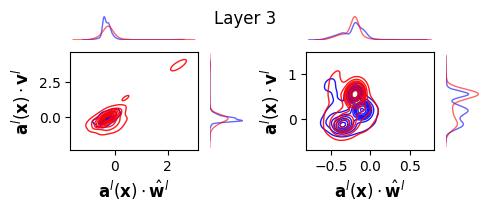

[[-0.06663382]]


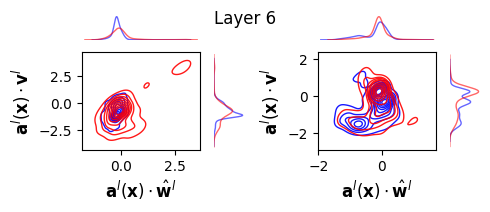

[[-0.02786635]]


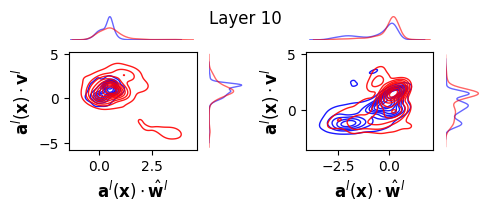

[[0.09401843]]


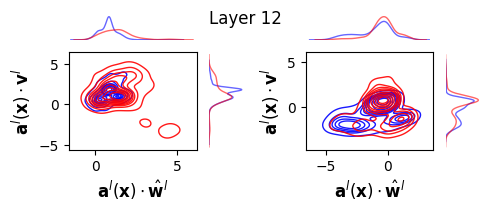

[[-0.07309652]]


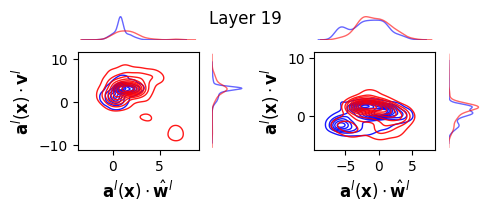

[[-0.02075308]]


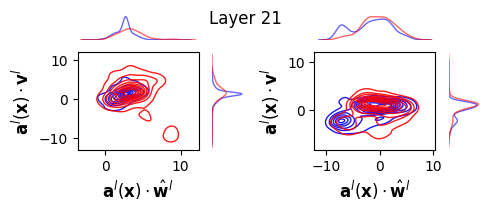

[[-0.03610775]]


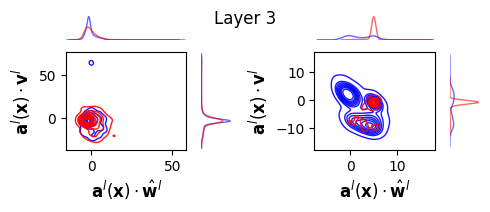

[[0.1746418]]


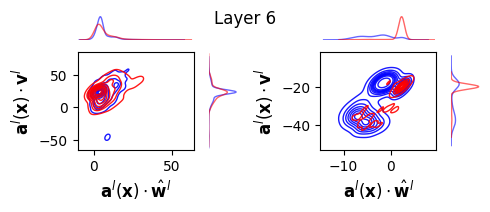

[[0.00994776]]


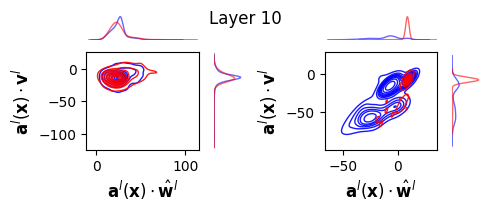

[[-0.0758298]]


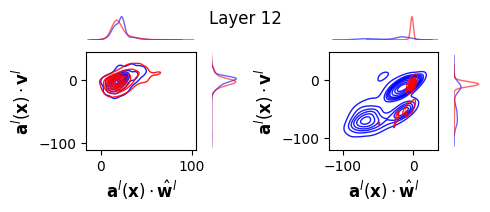

[[0.10534583]]


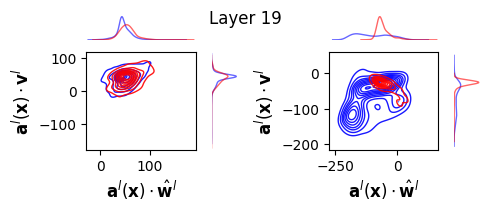

[[0.03375496]]


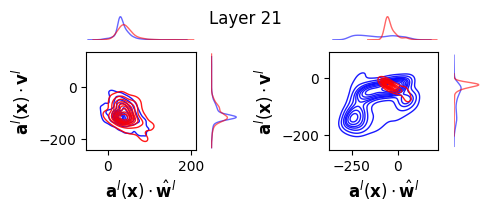

[[-0.10501594]]


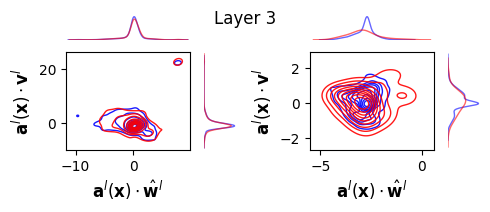

[[0.05759718]]


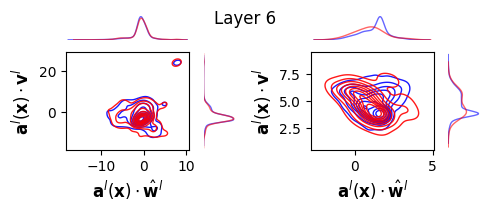

[[-0.21021834]]


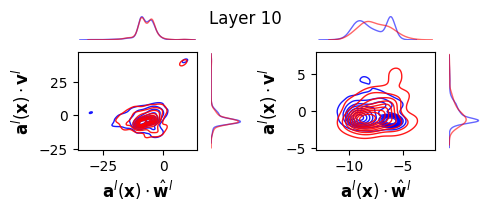

[[0.3947963]]


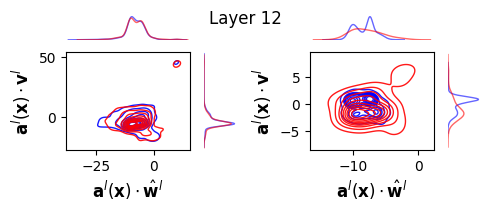

[[0.22950512]]


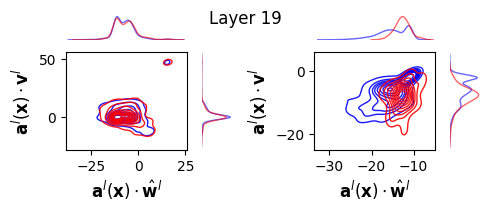

[[-0.0263428]]


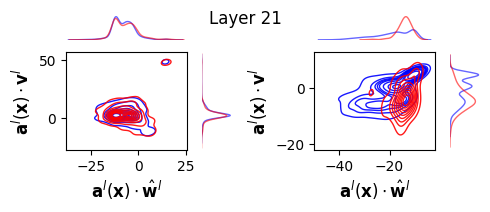

[[-0.01845279]]


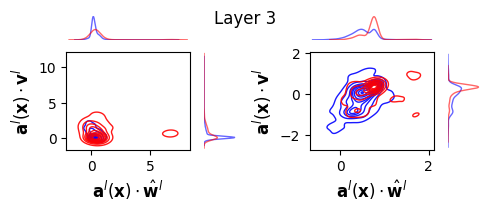

[[0.00894512]]


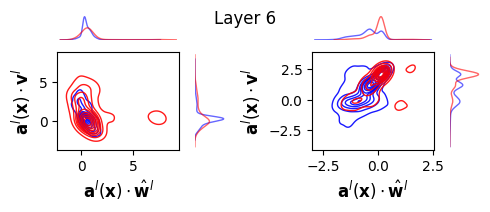

[[0.01830888]]


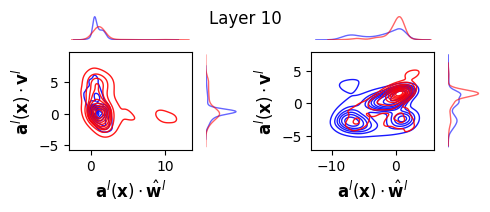

[[0.03103509]]


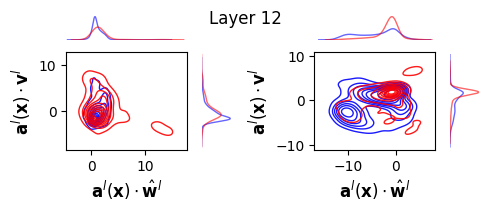

In [16]:
from sklearn.metrics import roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

def plot_kde_panel_with_marginals(fig, outer_position, x1, x2, y,
                                  title="", xlabel="", ylabel=""):
    """
    Draw a single panel (with top/right marginals) inside a 2x2 outer layout.
    """
    # Create a nested gridspec inside the given outer cell
    outer = fig.add_gridspec(3, 2)
    gs = outer[outer_position[0], outer_position[1]].subgridspec(4, 4)

    # Central 2D KDE
    ax_joint = fig.add_subplot(gs[1:,:-1])
    ax_marg_x = fig.add_subplot(gs[0,:-1], sharex=ax_joint)
    ax_marg_y = fig.add_subplot(gs[1:,-1], sharey=ax_joint)

    # Plot both classes
    for label, color in zip([0,1], ['blue', 'red']):
        sns.kdeplot(x=x1[y==label], y=x2[y==label],
                    ax=ax_joint, fill=False, color=color, alpha=0.9, levels=10, linewidths=1, bw_adjust=1.2)
        sns.kdeplot(x=x1[y==label], ax=ax_marg_x,
                    fill=False, alpha=0.6, color=color, linewidth=1, bw_adjust=1.2)
        sns.kdeplot(y=x2[y==label], ax=ax_marg_y,
                    fill=False, alpha=0.6, color=color, linewidth=1, bw_adjust=1.2)

    # Hide tick labels for marginals
    plt.setp(ax_marg_x.get_xticklabels(), visible=False)
    plt.setp(ax_marg_y.get_yticklabels(), visible=False)
    #  Remove tick labels and axis boxes for marginals
    ax_marg_x.set_axis_off()
    ax_marg_y.set_axis_off()

    # Labels & title
    ax_joint.set_xlabel(xlabel, size=12)
    ax_joint.set_ylabel(ylabel, size=12)
    # ax_joint.set_title(title, fontsize=9)
    # ax_marg_x.set_title(title, fontsize=9, pad=8)




    # Tighten layout within each panel
    plt.tight_layout()#pad=0.3)
    # Labels & title

    return ax_joint  # return central axis if needed


models = [( "meta-llama/Llama-3.2-3B", "meta-llama/Llama-3.2-3B-Instruct"), ("google/gemma-2-2b", "google/gemma-2-2b-it"),
          ("Qwen/Qwen2.5-3B", "Qwen/Qwen2.5-3B-Instruct"), ("allenai/OLMo-2-0425-1B", "allenai/OLMo-2-0425-1B-Instruct")]


def get_second_dir(X,y,  w, method='mean'):
    # normalize w
    w1 = w / (np.linalg.norm(w) + 1e-12)

    # projector onto orthogonal complement
    P_perp = np.eye(w1.size) - np.outer(w1, w1)
    if method == 'mean':

        Xp = X @ P_perp
        mu1 = Xp[y==1].mean(0)
        mu0 = Xp[y==0].mean(0)
        w2 = mu1 - mu0            # residual mean diff
        n = np.linalg.norm(w2) + 1e-12
        w2 = w2 / n
        auc = np.nan
    elif method == 'pca':
        Xc = X - X.mean(axis=0, keepdims=True)     # center data
        w1 = w / np.linalg.norm(w)

        # --- find new direction orthogonal to w with largest variance ---
        # deflate along w
        X_res = Xc - np.outer(Xc @ w1, w1)

        # SVD of the residual data
        _, _, Vt = np.linalg.svd(X_res, full_matrices=False)
        w2 = Vt[0]  
        auc = np.nan
    else:
        X_perp = X @ P_perp
        clf = LogisticRegression(max_iter=2000).fit(X_perp, y)
        w2 = clf.coef_.ravel()
        w2 = w2 / (np.linalg.norm(w2) + 1e-12)
        yhat = clf.predict(X_perp)
        auc = balanced_accuracy_score(y, yhat)
        auc = roc_auc_score(y, clf.decision_function(X_perp))

        w2_res = clf.coef_.ravel()
        w2_orig = P_perp @ w2_res
        w2 /= (np.linalg.norm(w2_orig) + 1e-12)

    return w2, auc

for pair in models:
    
    model_base, model_it = pair
    safe_base = re.sub(r'[\\/*?:"<>|]', "_", model_base)
    safe_it = re.sub(r'[\\/*?:"<>|]', "_", model_it)
    # Load A
    X_1b, v1b = load_harmbench(model_base, output_dir)
    layer_names = sorted(list(X_1b.keys()), key=lambda x: int(x.split('.')[-1]))
    yb = (v1b > 0).astype(int)
    # Load B
    X_1i, v1i = load_harmbench(model_it, output_dir)
    yi = (v1i > 0).astype(int)
    steering_vector_a = torch.load(os.path.join(f"{output_dir}/{safe_base}", "steering_vectors.pt"))
    steering_vector_b = torch.load(os.path.join(f"{output_dir}/{safe_it}", "steering_vectors.pt"))

    X_datab = []
    y_datab = []
    X_datai = []
    y_datai = []

    for data in datasets_list:
        X_d_b, y_d_b = load_datasets(model_base, data, output_dir)
        y_d_b = (y_d_b > 0).astype(int)
        X_datab.append(X_d_b)
        y_datab.append(y_d_b)

        X_d_i, y_d_i = load_datasets(model_it, data, output_dir)
        y_d_i = (y_d_i > 0).astype(int)
        X_datai.append(X_d_i)
        y_datai.append(y_d_i)


    t = 'toxic'
    res_base = {}
    res_it = {}
    layer_names = [layer for layer in layer_names if int(layer.split('.')[-1]) in [3, 19, 21, 10, 12, 6]]
    for i, layer in enumerate(layer_names):
        res_base[layer] = {}
        res_it[layer] = {}
        X_allb = []
        y_allb = []
        X_alli = []
        y_alli = []

        X_allb.append(X_1b[layer].float().numpy())
        y_allb.append(yb)
        X_alli.append(X_1i[layer].float().numpy())
        y_alli.append(yi)

        for data in X_datab:
            X_allb.append(data[layer].float().numpy())
        for labels in y_datab:
            y_allb.append(labels)

        for data in X_datai:
            X_alli.append(data[layer].float().numpy())
        for labels in y_datai:
            y_alli.append(labels)
        
        X_allb = np.concatenate(X_allb, axis=0)
        y_allb = np.concatenate(y_allb, axis=0)
        X_alli = np.concatenate(X_alli, axis=0)
        y_alli = np.concatenate(y_alli, axis=0)

        for method in ['mean', 'logreg', 'pca']:
            res_base[layer][method] = []
            res_it[layer][method] = []

        for method in ['mean', 'pca', 'logreg']:
            # Get first steering vector
            w1_b = steering_vector_a[layer][t].float().numpy()
            w1_it= steering_vector_b[layer][t].float().numpy()

            # Get second steering vector
            w2_base, auc_base = get_second_dir(X_1b[layer].float().numpy(), yb, w1_b, method=method)
            w2_it, auc_it = get_second_dir(X_1i[layer].float().numpy(), yi, w1_it, method=method)

            # Compute cosine similarity between the two second directions
            # x1_b = X_1b[layer].float().numpy() @ w1_b
            # x2_b = X_1b[layer].float().numpy() @ w2_base
            # x1_i = X_1i[layer].float().numpy() @ w1_it
            # x2_i = X_1i[layer].float().numpy() @ w2_it
            w1_b = w1_b / np.linalg.norm(w1_b)
            w1_it = w1_it / np.linalg.norm(w1_it)
            x1_b = X_allb @ w1_b
            x2_b = X_allb @ w2_base
            x1_i = X_alli @ w1_it
            x2_i = X_alli @ w2_it
            # print(x2_i.shape)

            res_base[layer][method].append((x1_b, x2_b))
            # print(res_base[layer][method][-1][0].shape)
            res_it[layer][method].append((x1_i, x2_i))
        
        print(cosine_similarity(w2_base.reshape(1,-1), w2_it.reshape(1,-1)))

        
        fig = plt.figure(figsize=(5,6))

        # (1) Base model - Mean
        # x1 = res_base[layer]['mean'][-1]
        # plot_kde_panel_with_marginals(
        #     fig, (0,0), x1[0], x1[1], y_allb,
        #     title="Base model - Mean",
        #     ylabel="2nd tox projection (mean)"
        # )

        # # (2) Instruct model - Mean
        # x1 = res_it[layer]['mean'][-1]
        # plot_kde_panel_with_marginals(
        #     fig, (0,1), x1[0], x1[1], y_alli,
        #     title="Instruct model - Mean"
        # )

        # # (3) Base model - LogReg
        # x1 = res_base[layer]['logreg'][-1]
        # plot_kde_panel_with_marginals(
        #     fig, (1,0), x1[0], x1[1], y_allb,
        #     title=f"Base model - LogReg (AUC: {auc_base:.2f})",
        #     xlabel=r"$\mathbf{a}^l(\mathbf{x}) \cdot \hat{\mathbf{u}}^l$",
        #     ylabel=r"$\mathbf{a}^l(\mathbf{x}) \cdot \hat{\mathbf{w}}^l$"
        # )

        # # (4) Instruct model - LogReg
        # x1 = res_it[layer]['logreg'][-1]
        # plot_kde_panel_with_marginals(
        #     fig, (1,1), x1[0], x1[1], y_alli,
        #     title=f"Instruct model - LogReg (AUC: {auc_it:.2f})",
        #     xlabel=r"$\mathbf{a}^l(\mathbf{x}) \cdot \hat{\mathbf{u}}^l$"
        # )

        # (3) Base model - LogReg
        x1 = res_base[layer]['pca'][-1]
        plot_kde_panel_with_marginals(
            fig, (0,0), x1[0], x1[1], y_allb,
            # title=f"Base model - PCA",
            xlabel=r"$\mathbf{a}^l(\mathbf{x}) \cdot \hat{\mathbf{w}}^l$",
            ylabel=r"$\mathbf{a}^l(\mathbf{x}) \cdot \mathbf{v}^l$",
        )

        # (4) Instruct model - LogReg
        x1 = res_it[layer]['pca'][-1]
        plot_kde_panel_with_marginals(
            fig, (0,1), x1[0], x1[1], y_alli,
            # title=f"Instruct model - PCA",
            xlabel=r"$\mathbf{a}^l(\mathbf{x}) \cdot \hat{\mathbf{w}}^l$",
            ylabel=r"$\mathbf{a}^l(\mathbf{x}) \cdot \mathbf{v}^l$",
        )
        # plt.legend(labels=['non-toxic', 'toxic'], loc='upper right', bbox_to_anchor=(1.15, 3.2))
        fig.suptitle(f"Layer {layer.split('.')[-1]}", fontsize=12, y=0.93)#, y=1.02)
        
        plt.tight_layout()
        
        os.makedirs(os.path.dirname(f"/home/fe/purelku/Desktop/Master_thesis/kde_panels/{safe_base}_vs_{safe_it}_{layer}_kde_panel.png"), exist_ok=True)
        plt.savefig(f"/home/fe/purelku/Desktop/Master_thesis/kde_panels/{safe_base}_vs_{safe_it}_{layer}_kde_panel.png", bbox_inches='tight', dpi=300)
        plt.savefig(f"/home/fe/purelku/Desktop/Master_thesis/kde_panels/{safe_base}_vs_{safe_it}_{layer}_kde_panel.svg",  format='svg', bbox_inches='tight', dpi=300)
        plt.show()
        plt.close()

        


In [ ]:
models = [ "meta-llama/Llama-3.2-3B", "meta-llama/Llama-3.2-3B-Instruct", "google/gemma-2-2b", "google/gemma-2-2b-it",
          "Qwen/Qwen2.5-3B", "Qwen/Qwen2.5-3B-Instruct",]# "allenai/OLMo-2-0425-1B", "allenai/OLMo-2-0425-1B-Instruct"]

mean_sv_final = {
            'Qwen/Qwen2.5-3B': {'a': 15, 'min_lambda': -2.8, 'min_avg_toxicity': np.float64(0.075), 'max_lambda': 2.8, 'max_avg_toxicity': np.float64(0.65)}, 
            'Qwen/Qwen2.5-3B-Instruct': {'a': 12, 'min_lambda': 0.1, 'min_avg_toxicity': np.float64(0.025), 'max_lambda': -3.0, 'max_avg_toxicity': np.float64(0.22)},
            'allenai/OLMo-2-0425-1B-Instruct': {'a': 15, 'min_lambda': -3.0, 'min_avg_toxicity': np.float64(0.025), 'max_lambda': -0.9, 'max_avg_toxicity': np.float64(0.23)}, 
            'allenai/OLMo-2-0425-1B': {'a': 14, 'min_lambda': -3.0, 'min_avg_toxicity': np.float64(0.01), 'max_lambda': 1.1, 'max_avg_toxicity': np.float64(0.415)}, 
            'google/gemma-2-2b-it': {'a': 14, 'min_lambda': 0.9, 'min_avg_toxicity': np.float64(0.005), 'max_lambda': -1.6, 'max_avg_toxicity': np.float64(0.195)},
            'meta-llama/Llama-3.2-3B-Instruct': {'a': 8, 'min_lambda': -3.0, 'min_avg_toxicity': np.float64(0.0), 'max_lambda': 2.4, 'max_avg_toxicity': np.float64(0.315)}, 
            'google/gemma-2-2b': {'a': 14, 'min_lambda': -3.0, 'min_avg_toxicity': np.float64(0.055), 'max_lambda': -0.3, 'max_avg_toxicity': np.float64(0.31)}, 
            'meta-llama/Llama-3.2-3B': {'a': 11, 'min_lambda': -2.5, 'min_avg_toxicity': np.float64(0.225), 'max_lambda': 2.8, 'max_avg_toxicity': np.float64(0.615)}
            }

for model_name in models:
    output_dir = "/data/erblina/Master_thesis"
    safe_model_name = re.sub(r'[\\/*?:"<>|]', "_", model_name)
    save_path = os.path.join(output_dir, safe_model_name)
   
    atten_tensors = load_safetensors(
        os.path.join(save_path, f"attention_states_pure.safetensors")
    )
    
    labels_before = np.load(f"{output_dir}/{safe_model_name}/labels.npy")
    layer_heads = {}
    all_head_data = []
    # if tox_dir not in ['pca', 'mean_head', 'diff']:
    #     tox_dir = 'mean'
    print(list(atten_tensors.keys()))
    layer_names = sorted(list(atten_tensors.keys()), key=lambda x: int(x.split('.')[2]))
    data_distance = []
    data_mean_sv = []

    for layer_name in layer_names:
        if layer_name not in layer_heads:
            layer_heads[layer_name] = {}

        overall_mean = atten_tensors[layer_name].float().mean(dim=0)
        toxic_behaviour = atten_tensors[layer_name][labels_before==1].float().mean(dim=0)  # (num_heads, head_dim)
        non_toxic_behaviour = atten_tensors[layer_name][labels_before==0].float().mean(dim=0)  # (num_heads, head_dim)
        head_diff = toxic_behaviour - non_toxic_behaviour  # (num_heads, head_dim)

        sign = toxic_behaviour.norm(dim=-1) - non_toxic_behaviour.norm(dim=-1)  # (num_heads,)
        sign_ = torch.sign(sign)  # (num_heads,)
        signed_scores_2 = 1 - F.cosine_similarity(toxic_behaviour, non_toxic_behaviour, dim=-1)  # non_toxic_behaviour, dim=-1) #[num_heads]
        # signed_scores_2 = signed_scores_2 * sign_
        data_distance.append(signed_scores_2.float().numpy() )

        
        
        r = toxic_behaviour.mean(0) - non_toxic_behaviour.mean(0)      # reference direction
        # r = toxic_behaviour - non_toxic_behaviour
        sims = F.cosine_similarity(atten_tensors[layer_name].float(), r.unsqueeze(0), dim=-1)
        signed_scores1 = F.cosine_similarity(atten_tensors[layer_name].float(), r.unsqueeze(0), dim=-1).mean(0)

        # signed_scores = signed_scores * sign_
        data_mean_sv.append(signed_scores1.float().numpy())
        # print(signed_scores1.shape, signed_scores_2.shape, sign_.shape)


    head_deltas = []   # layer_name -> (num_heads,) tensor
    head_mean = []
    for layer_name in layer_names:
        att = atten_tensors[layer_name].float()   # (N, H, D)
        labels = labels_before                    # (N,)

        # class-specific means per head: (H, D)
        toxic_mean     = att[labels == 1].mean(dim=0).mean(dim=0)
        nontoxic_mean  = att[labels == 0].mean(dim=0).mean(dim=0)

        # cosine distances from each example's head vector to the class means
        # att:         (N, H, D)
        # toxic_mean:  (H, D)  -> (1, H, D) for broadcast
        dist_to_toxic    = 1 - F.cosine_similarity(att, toxic_mean.unsqueeze(0),    dim=-1)  # (N, H)
        dist_to_nontoxic = 1 - F.cosine_similarity(att, nontoxic_mean.unsqueeze(0), dim=-1)  # (N, H)

        # Headwise Δ: mean distance difference for each head
        # Δ_head[h] = mean_n(dist_to_toxic[n,h]) - mean_n(dist_to_nontoxic[n,h])
        delta_head = dist_to_toxic.mean(dim=0) - dist_to_nontoxic.mean(dim=0)       # (H,)
        # print(f"{layer_name} Δ_heads: {delta_head.shape}")

        head_deltas.append(delta_head.numpy())  # or keep as tensor

        tox_mean = toxic_mean.mean(dim=0).numpy()
        nontox_mean = nontoxic_mean.mean(dim=0).numpy()

        dist_tox_mean = 1 - F.cosine_similarity(att, toxic_mean.unsqueeze(0), dim=-1).mean(dim=0).numpy()
        dist_nontox_mean = 1 - F.cosine_similarity(att, nontoxic_mean.unsqueeze(0), dim=-1).mean(dim=0).numpy()
        delta_mean = dist_tox_mean - dist_nontox_mean
        head_mean.append(delta_mean)
    
        


    ################## LAYER-WISE DELTA #####################    
    X_1, v1 = load_harmbench(model_name, output_dir)
    layers = sorted(list(X_1.keys()), key=lambda x: int(x.split('.')[-1]))

    print(f"\n=== Processing model: {model_name} ===")
    p_list, null_list = [], []
    results = []
    for layer in layers:
        X = X_1[layer].float().numpy()
        # y = (v1 > 0).astype(int)
        y = v1.astype(int)

        # --- B. Contrastive Δ (mean distance difference) ---
        dist_to_class_mean = []
        for c in [0, 1]:

            cls_vecs = X[y == c].mean(0, keepdims=True)
            dists = 1 - cosine_similarity(X, cls_vecs).squeeze()

            dist_to_class_mean.append(dists)
        Δ = np.mean(dist_to_class_mean[1]) - np.mean(dist_to_class_mean[0]) 
        results.append(Δ)    
        
    
    delta_heads_all = np.array(head_deltas)

    delta_layers_all = np.array(results)

    print(delta_heads_all.shape, delta_layers_all.shape)

    # Sort heads by delta
    # sorted_indices = np.argsort(delta_heads_all, axis=1)[:, ::-1]  # descending order
    # ata_norm = np.take_along_axis(delta_heads_all, sorted_indices, axis=1)
        
    # ---------- SORT HEADS GLOBALLY BY MEAN |Δ| ----------
    L, H = delta_heads_all.shape
    head_order = np.argsort(delta_heads_all, axis=1)              # descending
    delta_sorted = np.take_along_axis(delta_heads_all, head_order, axis=1)  # (L, H)

    data_distance = np.array(data_distance).squeeze()

    data_mean_sv = np.array(data_mean_sv) 
    

    
    # ---------- PLOT HEATMAP + LAYER Δ LINE ----------
    fig, ax = plt.subplots(1, 2, figsize=(7, 3))

    mat = data_mean_sv
    mat_T = mat.T
    L, H = mat.shape
    im = sns.heatmap(
        # delta_sorted.T,
        mat_T,
        cmap='bwr',
        center=0,
        cbar_kws={'label': r'$d^{l,h}$'},
        ax=ax[0]
    )
    

    # flatten matrix
    flat = mat.reshape(-1)

    # get indices of top-k largest values
    top_k = mean_sv_final[model_name]['a']
    top_indices = np.argsort(flat)[-top_k:]     # sorted ascending → take last k

    # convert to 2D indices
    layer_idx, head_idx = np.unravel_index(top_indices, (L, H))

    from matplotlib.patches import Rectangle

    for layer, head in zip(layer_idx, head_idx):
        # Rectangle at (x=layer, y=head), width=1, height=1
        rect = Rectangle(
            (layer, head),        # (x, y)
            1, 1,                 # width, height
            fill=False,           # hollow
            edgecolor='black',
            linewidth=1.8
        )
        ax[0].add_patch(rect)
    ax[0].set_title(f" {model_name}")
    ax[0].set_xlabel("Layer")
    ax[0].set_ylabel("Head")

    # x ticks = layer indices
    # ax[0].set_xticks(np.arange(L) + 0.5)
    # ax[0].set_xticklabels([str(i) for i in range(L)], rotation=0)



    mat = data_distance
    mat_T = mat.T
    L, H = mat.shape
    im = sns.heatmap(
        # delta_sorted.T,
        mat_T,
        cmap='bwr',
        center=0,
        cbar_kws={'label': r'$d^{l,h}$'},
        ax=ax[1]
    )
    

    # flatten matrix
    flat = mat.reshape(-1)

    # get indices of top-k largest values
    top_k = mean_sv_final[model_name]['a']
    top_indices = np.argsort(flat)[-top_k:]     # sorted ascending → take last k

    # convert to 2D indices
    layer_idx, head_idx = np.unravel_index(top_indices, (L, H))

    from matplotlib.patches import Rectangle

    for layer, head in zip(layer_idx, head_idx):
        # Rectangle at (x=layer, y=head), width=1, height=1
        rect = Rectangle(
            (layer, head),        # (x, y)
            1, 1,                 # width, height
            fill=False,           # hollow
            edgecolor='black',
            linewidth=1.8
        )
        ax[1].add_patch(rect)
    ax[1].set_title(f" {model_name}")
    ax[1].set_xlabel("Layer")
    ax[1].set_ylabel("Head")

    
    
    plt.tight_layout()
    plt.savefig(f"/home/fe/purelku/Desktop/Master_thesis/kde_panels/{safe_model_name}_head_mean_sv.svg",  format='svg', bbox_inches='tight', dpi=300)

    plt.show()
    plt.close()

    

    fig, ax = plt.subplots(figsize=(6, 3))
    mean_head2 = delta_heads_all.max(axis=1)
    mean_head = np.array(head_mean).mean(axis=1)

    mat = data_mean_sv

    max_head = mat.mean(axis=1)
    
    ax.plot(mean_head, label=r'$mean(\Delta^{l,h})$', color='g', lw=2)
    # ax.plot(mean_head2, label=r'$mean(d^{l,h})$', color='orange', lw=2)
    ax.plot(mean_head2, label=r'$max(\Delta^{l,h})$', color='orange', lw=2)
    ax.plot(delta_layers_all, label=r'$\Delta^{l}$', color='k', lw=2)
    ax.set_title(model_name)
    ax.set_xlabel("Layer")
    ax.set_ylabel(r"\Delta")
    ax.legend(loc='upper left', bbox_to_anchor=(1.05,1.0))
    plt.tight_layout()
    plt.show()

    
